The goal of the project is to build a model that can rate the sentiment of a Tweet based on its content.
The tweet can either be classified as:
- Positive
- Negative 
- Neutral

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
from collections import Counter

importing the Libraries

In [ ]:
#Loading the dataset
data = pd.read_csv('../data/judge-1377884607_tweet_product_company.csv',encoding='latin1')
data.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


Our dataset has three columns: tweet_text, emotion in tweet is directed at, and is there an emotion at brand or topic.
- Tweet test has 1 missing value.
- emotion in tweet is directed at 5802
- Our dataset has three columns: tweet_text, emotion in tweet is directed at has no missing value


In [ ]:
# renaming the columns
data_new = data.rename(columns={
'tweet_text': 'tweet',
'emotion_in_tweet_is_directed_at':'product',
'is_there_an_emotion_directed_at_a_brand_or_product':'sentiment'
})

### Exploratory Data Analysis
In explatory data analysis, the following will be done:
- Class distribution for the sentiment classes(positive, negative, and neutral)
- Most common words using vectorizer(TF-IDF)
- Missing values and duplicate checks

In [ ]:
data_new.shape

(9093, 3)

In [ ]:
data_new.isnull().sum()

tweet           1
product      5802
sentiment       0
dtype: int64

In [ ]:
df = data_new

In [ ]:
# dealing with the missing values. Do we drop of fill?
# for tweet, we will drop that one missing value

df = df.dropna(subset=['tweet']) # dropped the one missing tweet
df.isnull().sum() 


tweet           0
product      5801
sentiment       0
dtype: int64

In [ ]:
# Duplicates
duplicates = df['tweet'].duplicated().sum()  # check for duplicates in the 'tweet' column
print(f"Duplicate tweets: {duplicates}")
df = df.drop_duplicates(subset='tweet').reset_index(drop=True) # drop duplicates based on the 'tweet' column and reset index
print(f"Shape after removing duplicates: {df.shape}")

Duplicate tweets: 27
Shape after removing duplicates: (9065, 3)


## Class Distribution

In [ ]:

df['sentiment'].value_counts()   #### no of classes subject to change


sentiment
No emotion toward brand or product    5372
Positive emotion                      2968
Negative emotion                       569
I can't tell                           156
Name: count, dtype: int64

In [ ]:
df['sentiment'].value_counts(normalize=True) ### percentage of each class

sentiment
No emotion toward brand or product    0.592609
Positive emotion                      0.327413
Negative emotion                      0.062769
I can't tell                          0.017209
Name: proportion, dtype: float64

#### Text Structure Analysis

In [ ]:
df['text_length'] = df['tweet'].apply(len) ### length of the text in each tweet
df['word_count'] = df['tweet'].apply(lambda x: len(str(x).split())) ### number of words in each tweet
df[['text_length','word_count']].describe() ### summary statistics of the text length and word count

,text_length,word_count
count,9065.000000,9065.000000
mean,104.969333,17.767347
std,27.191156,4.960616
min,11.000000,2.000000
25%,86.000000,14.000000
50%,109.000000,18.000000
75%,126.000000,21.000000
max,178.000000,33.000000


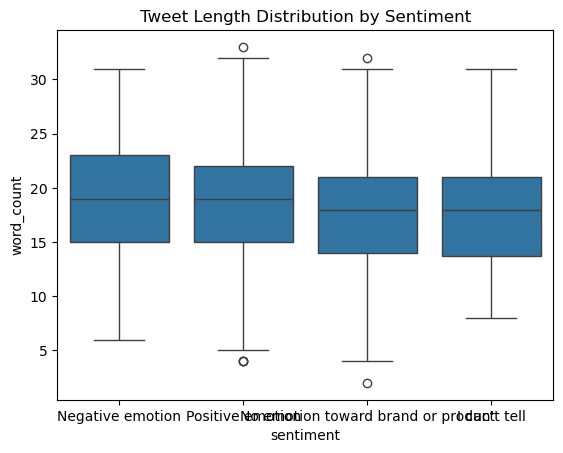

In [ ]:
 
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title("Tweet Length Distribution by Sentiment")
plt.show()

In [ ]:
df.groupby('sentiment')['word_count'].mean() ### average word count for each sentiment

sentiment
I can't tell                          17.628205
Negative emotion                      18.746924
No emotion toward brand or product    17.437640
Positive emotion                      18.183625
Name: word_count, dtype: float64

#### Most Common Words

In [ ]:
stop_words = set(stopwords.words('english'))


def get_clean_tokens(text):
    if not isinstance(text, str):
        return []
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtag symbols (keep the word)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stop words
    
    tokens = [word for word in tokens if word not in stop_words]
    # Remove short tokens (1-2 chars)
    tokens = [t for t in tokens if len(t) > 2]
    return tokens

In [ ]:
positive_emotion = []
negative_emotion = []


for text, sentiment in zip(df['tweet'], df['sentiment']):
    tokens = get_clean_tokens(text)
    if sentiment == 'Positive emotion':
        positive_emotion.extend(tokens)

    elif sentiment == 'Negative emotion':
        negative_emotion.extend(tokens)

# Top 15 Positive tweets
print("\n=== Top 15 Words in POSITIVE Sentiment ===")
print(Counter(positive_emotion).most_common(15))

# Top 15 Negative tweets
print("\n=== Top 15 Words in NEGATIVE Sentiment ===")
print(Counter(negative_emotion).most_common(15))


=== Top 15 Words in POSITIVE Sentiment ===
[('sxsw', 3102), ('link', 1206), ('ipad', 1191), ('apple', 835), ('google', 634), ('store', 538), ('iphone', 522), ('app', 394), ('new', 359), ('austin', 288), ('popup', 218), ('android', 196), ('amp', 178), ('launch', 160), ('get', 158)]

=== Top 15 Words in NEGATIVE Sentiment ===
[('sxsw', 578), ('ipad', 194), ('iphone', 155), ('google', 140), ('link', 101), ('apple', 99), ('app', 60), ('store', 44), ('new', 43), ('like', 39), ('circles', 33), ('social', 30), ('apps', 30), ('people', 29), ('design', 28)]


<Axes: xlabel='sentiment'>

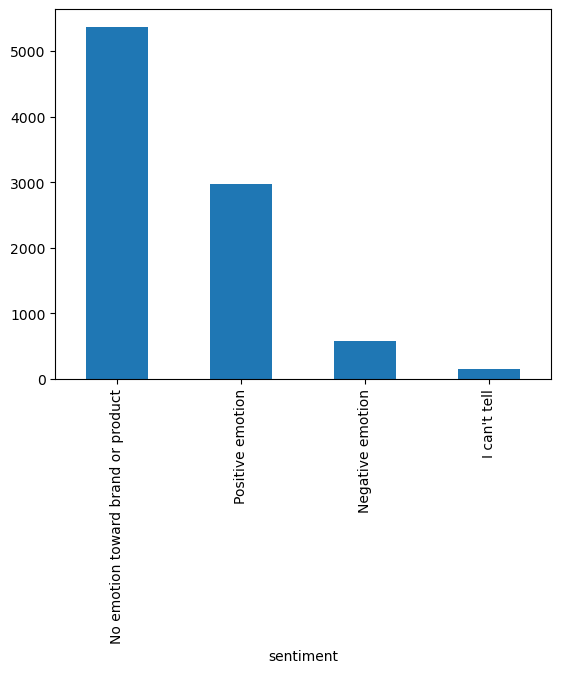

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')